In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn import preprocessing
from sklearn.preprocessing import MultiLabelBinarizer
import seaborn as sns
from sklearn import metrics
from sklearn.feature_extraction import text 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import re 
from rapidfuzz import process, fuzz

In [2]:
df_admits = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')

In [2]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')

In [131]:
pd.set_option('max_colwidth', None)

In [40]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
df_pat.head(10)

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13
5,10000102,F,27,2136,2008 - 2010,NaN
6,10000108,M,25,2163,2014 - 2016,NaN
7,10000115,M,24,2154,2017 - 2019,NaN
8,10000117,F,48,2174,2008 - 2010,NaN
9,10000161,M,60,2163,2020 - 2022,NaN


In [ ]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


In [ ]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [45]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_icd_proc,how = 'left', on = 'icd_code')
df_admit_diagnosis.drop(columns= ['subject_id_y'], inplace = True)
df_admit_diagnosis.rename(columns={'long_title_x': 'icd_diagnosis_name','long_title_y':'proc_name','subject_id_x':'subject_id'}, inplace=True)
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_pat[['subject_id', 'anchor_age','gender']],how = 'left', on = 'subject_id')

In [46]:
# Replace all NaN with 'No Diagnosis'
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis['proc_name'] = df_admit_diagnosis['proc_name'].fillna('No Procedure')
df_admit_diagnosis['icd_code'] = df_admit_diagnosis['icd_code'].fillna('No ICD Code')
df_admit_diagnosis[df_admit_diagnosis['proc_name'].isna()]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender


In [47]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,1.0,5723,9.0,9.0,Portal hypertension,NaN,No Procedure,52,F
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,2.0,78959,9.0,9.0,Other ascites,NaN,No Procedure,52,F
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,52,F
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,52,F


In [ ]:
print("\n".join(map(str, df_admit_diagnosis.icd_diagnosis_name.unique())))

Ensure normalisation of icd_diagnosis_name and proc_name

In [42]:
my_stop_words = ['term','episode', 'face', 'facial','mouth','home','legs','pain'
                 ,'procedure','procedures','diagnosis','weight','adult','child','unspecified','primary','secondary','other','long'
                 ,'system', 'due', 'related', 'associated', 'organ', 'tissue', 'area', 'region', 'tract'
                 ,'side', 'lobe', 'part', 'left', 'right', 'bilateral', 'upper', 'lower', 'anterior','encounter'
                 ,'posterior', 'icd', 'code','type', 'specified', 'classification', 'negative','positive'
                 ,'history', 'present', 'past','recent', 'new', 'old','accessory','adhesive','body', 'blood'
                 ,'classified','unclassified','cause','causing','reaction','status','current','complication'
                 ,'do','not','classified','elsewhere','severity','without','history','personal','cause','initial']
combined_stop_words = list(text.ENGLISH_STOP_WORDS.union(my_stop_words))


def normalise_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)      # remove punctuation
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    tokens = text.split()                    # Tokenize
    filtered_tokens = [word for word in tokens if word not in combined_stop_words]  # Remove stop words
    return ' '.join(filtered_tokens)

In [22]:
# Testing normalisation with subset
df_admit_diagnosis_subset = df_admit_diagnosis.loc[1:10000,:]
df_admit_diagnosis_subset['diagnosis_clean'] = df_admit_diagnosis_subset['icd_diagnosis_name'].apply(normalise_text)

C:\Users\smahmood\AppData\Local\Temp\ipykernel_20160\1531015921.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_admit_diagnosis_subset['diagnosis_clean'] = df_admit_diagnosis_subset['icd_diagnosis_name'].apply(normalise_text)


In [23]:
unique_diagnoses = df_admit_diagnosis_subset['diagnosis_clean'].dropna().unique()

In [43]:
def standardise_similar_entries(unique_values, threshold=80):
    standardisation_map = {}
    value_list = list(unique_values)
    
    for i, current_value in enumerate(value_list):
        if current_value is None or current_value == '':
            continue  # skip empty
        
        if current_value in standardisation_map:
            continue  # already mapped
        
        # Create a list excluding current_value
        others = value_list[:i] + value_list[i+1:]
        
        match = process.extractOne(
            current_value,
            others,
            processor=None,
            scorer=fuzz.token_sort_ratio,
            score_cutoff=threshold
        )
        
        if match:
            matched_value = match[0]
            standardisation_map[matched_value] = current_value
            standardisation_map[current_value] = current_value
        else:
            # map self if no close match found
            standardisation_map[current_value] = current_value
            
    return standardisation_map

In [25]:
standardised_map_subset = standardise_similar_entries(unique_diagnoses)

In [26]:
df_admit_diagnosis_subset['diagnosis_name'] = df_admit_diagnosis_subset['diagnosis_clean'].map(standardised_map_subset).fillna(df_admit_diagnosis_subset['icd_diagnosis_name'])

C:\Users\smahmood\AppData\Local\Temp\ipykernel_20160\3282736867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_admit_diagnosis_subset['diagnosis_name'] = df_admit_diagnosis_subset['diagnosis_clean'].map(standardised_map_subset).fillna(df_admit_diagnosis_subset['icd_diagnosis_name'])


In [27]:
df_admit_diagnosis_subset.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender,diagnosis_clean,diagnosis_name
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,78959,9.0,9.0,Other ascites,NaN,No Procedure,52,F,ascites,ascites
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F,cirrhosis liver mention alcohol,cirrhosis liver mention alcohol
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,52,F,viral hepatitis c hepatic coma,viral hepatitis c hepatic coma
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,52,F,chronic airway obstruction,chronic airway obstruction
5,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,29680,9.0,9.0,"Bipolar disorder, unspecified",NaN,No Procedure,52,F,bipolar disorder,bipolar disorder


In [48]:
## Actual 
df_admit_diagnosis['diagnosis_clean'] = df_admit_diagnosis['icd_diagnosis_name'].apply(normalise_text)
df_admit_diagnosis['procedure_clean'] = df_admit_diagnosis['proc_name'].apply(normalise_text)

unique_diagnoses = df_admit_diagnosis['diagnosis_clean'].dropna().unique()
unique_proc = df_admit_diagnosis['procedure_clean'].dropna().unique()

In [49]:
# Map the cleaned diagnosis to the standardised form
standardised_map_diagnosis = standardise_similar_entries(unique_diagnoses)
standardised_map_proc = standardise_similar_entries(unique_proc)

In [50]:
df_admit_diagnosis['diagnosis_name'] = df_admit_diagnosis['diagnosis_clean'].map(standardised_map_diagnosis).fillna(df_admit_diagnosis['icd_diagnosis_name'])
df_admit_diagnosis['procedure_name'] = df_admit_diagnosis['procedure_clean'].map(standardised_map_proc).fillna(df_admit_diagnosis['proc_name'])

In [51]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender,diagnosis_clean,procedure_clean,diagnosis_name,procedure_name
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Portal hypertension,NaN,No Procedure,52,F,portal hypertension,,portal hypertension,No Procedure
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Other ascites,NaN,No Procedure,52,F,ascites,,ascites,No Procedure
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F,cirrhosis liver mention alcohol,,cirrhosis liver mention alcohol,No Procedure
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,52,F,viral hepatitis c hepatic coma,,viral hepatitis c hepatic coma,No Procedure
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,52,F,chronic airway obstruction,excision anus,chronic airway obstruction,excision anus


In [ ]:
print("\n".join(map(str, df_admit_diagnosis.diagnosis_name.unique())))

In [53]:
diagnosis_counts = df_admit_diagnosis.diagnosis_name.value_counts()
proc_counts = df_admit_diagnosis.procedure_name.value_counts()

# Get the top 200 ICD codes by frequency
top_200_diagnosis = df_admit_diagnosis['diagnosis_name'].value_counts().nlargest(201).index
top_200_proc = df_admit_diagnosis['procedure_name'].value_counts().nlargest(201).index

# Map ICD codes — keep top 200, replace others with 'Other Code'
df_admit_diagnosis['diagnosis_converted'] = df_admit_diagnosis['diagnosis_name'].apply(
    lambda x: str(x) if x in top_200_diagnosis else 'Other Diagnosis'
)
df_admit_diagnosis['procedure_converted'] = df_admit_diagnosis['procedure_name'].apply(
    lambda x: str(x) if x in top_200_proc else 'Other Procedure'
)

df_admit_diagnosis.drop(columns = ['icd_version_y','icd_version_x','edregtime','edouttime','deathtime','admit_provider_id','hospital_expire_flag','icd_diagnosis_name','proc_name',
                                         'seq_num','icd_code','language','icd_version','diagnosis_clean','diagnosis_name','procedure_clean','procedure_name'],inplace = True)

In [54]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,diagnosis_converted,procedure_converted
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,portal hypertension,No Procedure
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,ascites,No Procedure
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,Other Diagnosis,No Procedure
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,viral hepatitis c hepatic coma,No Procedure
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,chronic airway obstruction,excision anus


In [ ]:
pd.set_option('display.max_rows', 10)
print(df_admit_diagnosis.procedure_converted.value_counts().head(10000))

In [140]:
# Group first to reduce data size
df_admit_diagnosis_grouped = df_admit_diagnosis.groupby(['hadm_id', 'subject_id']).agg({  
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'admittime':'first',
     'dischtime':'first',
     'insurance':'first',
     'marital_status': 'first',
     'race':'first',
     'anchor_age': 'first',
     'gender':'first',
     'diagnosis_converted': lambda x: set(x),
     'procedure_converted': lambda x: set(x),
     }).reset_index()
df_admit_diagnosis_grouped.head(5)  

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,marital_status,race,anchor_age,gender,diagnosis_converted,procedure_converted
0,20000019,10467237,EW EMER.,EMERGENCY ROOM,HOME,2159-03-20 21:08:00,2159-03-23 16:54:00,Medicaid,SINGLE,HISPANIC/LATINO - GUATEMALAN,76,F,"{hyperlipidemia, bandemia, diabetes mellitus mention ii stated uncontrolled, acute kidney failure, malignant essential hypertension, asthma, hyposmolality andor hyponatremia, Other Diagnosis}","{biopsy structure, suture laceration palate, No Procedure, repair urethra, diagnostic lymphatic structures}"
1,20000024,16925328,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,2151-05-25 21:44:00,2151-05-26 18:36:00,Medicare,SINGLE,WHITE,84,F,"{Other Diagnosis, osteoporosis pathological fracture, malignant essential hypertension, falling}",{No Procedure}
2,20000034,19430048,DIRECT OBSERVATION,PHYSICIAN REFERRAL,None,2174-05-22 19:13:00,2174-05-24 17:27:00,Medicare,SINGLE,BLACK/CARIBBEAN ISLAND,72,M,"{severe proteincalorie malnutrition, drug chemical induced diabetes mellitus diabetic chronic kidney disease, use insulin, hypoosmolality hyponatremia, retention urine, alcoholic cirrhosis liver ascites, mass index, Other Diagnosis, malignant neoplasm main bronchus, protein deficiency anemia, transient ischemic attack tia cerebral infarction residual deficits, chronic kidney disease stage iii moderate, insomnia, venous thrombosis nec, benign prostatic hyperplasia urinary symptoms, nicotine dependence, hypertensive chronic kidney disease stage stage chronic kidney disease chronic kidney disease}","{physical rehabilitation diagnostic audiology rehabilitation hearing treatment, No Procedure}"
3,20000041,18910522,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,2143-09-03 07:15:00,2143-09-06 13:50:00,Private,SINGLE,WHITE,62,F,"{hyperlipidemia, bariatric surgery, malignant essential hypertension, esophageal reflux, obesity, mass index, Other Diagnosis, venous thrombosis nec}","{diagnostic lymphatic structures, No Procedure, biopsy structure}"
4,20000045,13413708,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,2138-05-21 16:25:00,2138-05-29 02:05:00,Private,DIVORCED,WHITE,51,F,"{fall stairs ladders water transport injuring person, covid, urinary infection site, sepsis organism, Other Diagnosis, escherichia coli e coli diseases, nicotine dependence, disorders phosphorus metabolism}",{No Procedure}


In [141]:
# Assign admission ranks throughout time
# Readmission is within 30 days of discharge and next admission so insert flag

df_admit_diagnosis_grouped['admittime'] = pd.to_datetime(df_admit_diagnosis_grouped['admittime'])
df_admit_diagnosis_grouped['dischtime'] = pd.to_datetime(df_admit_diagnosis_grouped['dischtime'])

df_admit_diagnosis_grouped['admission_rank'] = df_admit_diagnosis_grouped.groupby('subject_id')['admittime'].rank(method='dense', ascending=True)
df_admit_diagnosis_grouped.sort_values(by = ['admission_rank'],ascending= True, inplace= True)
# Get next admission's out time for each patient
df_admit_diagnosis_grouped['last_dischtime'] = df_admit_diagnosis_grouped.groupby('subject_id')['dischtime'].shift(1)

# Calculate days until next visit
df_admit_diagnosis_grouped['days_from_last'] = (df_admit_diagnosis_grouped['admittime'] - df_admit_diagnosis_grouped['last_dischtime']).dt.days

# Create readmission flag (1 if last visit is within 30 days, else 0)
df_admit_diagnosis_grouped['readmission'] = df_admit_diagnosis_grouped['days_from_last'].apply(lambda x: 1 if pd.notnull(x) and x <= 30 and x >= 0 else 0)

#df_admit_diagnosis_grouped[df_admit_diagnosis_grouped['subject_id'] == 10000032]

In [142]:
# one hot encode the text columns
df_admit_diagnosis_encoded = df_admit_diagnosis_grouped.drop(columns= ['admittime','dischtime','last_dischtime','days_from_last', 
                                                                       'admission_rank']) # drop irrelevant cols

cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race','gender','marital_status']
df_admit_diagnosis_encoded = pd.get_dummies(df_admit_diagnosis_encoded, columns=cols_to_encode, drop_first=True,dtype=int)
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


,hadm_id,subject_id,anchor_age,diagnosis_converted,procedure_converted,readmission,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_CLINIC REFERRAL,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,admission_location_PACU,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,admission_location_WALK-IN/SELF REFERRAL,discharge_location_AGAINST ADVICE,discharge_location_ASSISTED LIVING,discharge_location_CHRONIC/LONG TERM ACUTE CARE,discharge_location_DIED,discharge_location_HEALTHCARE FACILITY,discharge_location_HOME,discharge_location_HOME HEALTH CARE,discharge_location_HOSPICE,discharge_location_OTHER FACILITY,discharge_location_PSYCH FACILITY,discharge_location_REHAB,discharge_location_SKILLED NURSING FACILITY,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,race_ASIAN,race_ASIAN - ASIAN INDIAN,race_ASIAN - CHINESE,race_ASIAN - KOREAN,race_ASIAN - SOUTH EAST ASIAN,race_BLACK/AFRICAN,race_BLACK/AFRICAN AMERICAN,race_BLACK/CAPE VERDEAN,race_BLACK/CARIBBEAN ISLAND,race_HISPANIC OR LATINO,race_HISPANIC/LATINO - CENTRAL AMERICAN,race_HISPANIC/LATINO - COLUMBIAN,race_HISPANIC/LATINO - CUBAN,race_HISPANIC/LATINO - DOMINICAN,race_HISPANIC/LATINO - GUATEMALAN,race_HISPANIC/LATINO - HONDURAN,race_HISPANIC/LATINO - MEXICAN,race_HISPANIC/LATINO - PUERTO RICAN,race_HISPANIC/LATINO - SALVADORAN,race_MULTIPLE RACE/ETHNICITY,race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,race_OTHER,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_SOUTH AMERICAN,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - EASTERN EUROPEAN,race_WHITE - OTHER EUROPEAN,race_WHITE - RUSSIAN,gender_M,marital_status_MARRIED,marital_status_SINGLE,marital_status_WIDOWED
141961,22595853,10000032,52,"{portal hypertension, tobacco use, bipolar ii disorder, viral hepatitis c hepatic coma, posttraumatic stress disorder chronic, chronic airway obstruction, Other Diagnosis, ascites}","{No Procedure, excision anus}",0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
155119,22841357,10000032,52,"{tobacco use disorder, viral hepatitis c hepatic coma, hyposmolality andor hyponatremia, chronic airway obstruction, Other Diagnosis, thrombocytopenia, ascites}","{suture laceration palate, No Procedure, excision anus}",0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
495453,29079034,10000032,52,"{resuscitate, bipolar ii disorder, tobacco use disorder, hyperpotassemia, hyposmolality andor hyponatremia, Other Diagnosis, dependence machines supplemental oxygen, chronic hepatitis c mention hepatic coma, chronic airway obstruction, ascites}","{suture laceration palate, excision anus, No Procedure, operation bone injury phalanges hand}",1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
313493,25742920,10000032,52,"{diarrhea, tobacco use disorder, hyperpotassemia, dependence machines supplemental oxygen, Other Diagnosis, hyposmolality andor hyponatremia, chronic hepatitis c mention hepatic coma, chronic airway obstruction, ascites}","{suture laceration palate, No Procedure, excision anus}",1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [143]:
for col in ['diagnosis_converted', 'procedure_converted']:
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(df_admit_diagnosis_encoded[col])
    df_encoded = pd.DataFrame.sparse.from_spmatrix(
        X,
        index=df_admit_diagnosis_encoded['hadm_id'],
        columns=[f"{c}" for c in mlb.classes_]
    )
    df_admit_diagnosis_encoded = df_admit_diagnosis_encoded.merge(
        df_encoded, left_on='hadm_id', right_index=True, how='left'
    )

In [144]:
pd.set_option('display.max_columns', None)
df_admit_diagnosis_encoded.head()

,hadm_id,subject_id,anchor_age,diagnosis_converted,procedure_converted,readmission,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_CLINIC REFERRAL,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,admission_location_PACU,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,admission_location_WALK-IN/SELF REFERRAL,discharge_location_AGAINST ADVICE,discharge_location_ASSISTED LIVING,discharge_location_CHRONIC/LONG TERM ACUTE CARE,discharge_location_DIED,discharge_location_HEALTHCARE FACILITY,discharge_location_HOME,discharge_location_HOME HEALTH CARE,discharge_location_HOSPICE,discharge_location_OTHER FACILITY,discharge_location_PSYCH FACILITY,discharge_location_REHAB,discharge_location_SKILLED NURSING FACILITY,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,race_ASIAN,race_ASIAN - ASIAN INDIAN,race_ASIAN - CHINESE,race_ASIAN - KOREAN,race_ASIAN - SOUTH EAST ASIAN,race_BLACK/AFRICAN,race_BLACK/AFRICAN AMERICAN,race_BLACK/CAPE VERDEAN,race_BLACK/CARIBBEAN ISLAND,race_HISPANIC OR LATINO,race_HISPANIC/LATINO - CENTRAL AMERICAN,race_HISPANIC/LATINO - COLUMBIAN,race_HISPANIC/LATINO - CUBAN,race_HISPANIC/LATINO - DOMINICAN,race_HISPANIC/LATINO - GUATEMALAN,race_HISPANIC/LATINO - HONDURAN,race_HISPANIC/LATINO - MEXICAN,race_HISPANIC/LATINO - PUERTO RICAN,race_HISPANIC/LATINO - SALVADORAN,race_MULTIPLE RACE/ETHNICITY,race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,race_OTHER,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_SOUTH AMERICAN,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - EASTERN EUROPEAN,race_WHITE - OTHER EUROPEAN,race_WHITE - RUSSIAN,gender_M,marital_status_MARRIED,marital_status_SINGLE,marital_status_WIDOWED,Other Diagnosis,abnormal coagulation profile,accident,accidents occurring place,accidents occurring residential institution,acidosis,acquired hypothyroidism,acute chronic diastolic congestive heart failure,acute chronic diastolic heart failure,acute chronic systolic congestive heart failure,acute chronic systolic heart failure,acute kidney failure,acute kidney failure tubular necrosis,acute posthemorrhagic anemia,acute respiratory failure,adverse effect antineoplastic immunosuppressive drugs,alcohol abuse,alcoholic cirrhosis liver ascites,anemia chronic kidney disease,antineoplastic immunotherapy,anxiety disorder,anxiety state,aortic valve disorders,aortocoronary bypass,ascites,asthma,asthma uncomplicated,atherosclerotic heart disease native coronary artery unstable angina pectoris,atrial fibrillation,atrial flutter,atypical depressive disorder,bacteremia,bandemia,bariatric surgery,benign prostatic hyperplasia urinary symptoms,bipolar ii disorder,bloodsampling abnormal patient later mention misadventure time,cardiac dysrhythmias,cardiac pacemaker situ,cardiomyopathies,cellulitis abscess leg foot,cellulitis limb,chest,chronic,chronic airway obstruction,chronic hepatitis c mention hepatic coma,chronic kidney disease stage iii moderate,chronic kidney disease stage severe,chronic obstructive pulmonary disease,chronic pulmonary embolism,chronic pulmonary heart diseases,cirrhosis liver,congestive heart failure,constipation,contact suspected exposure covid,contact suspected exposure viral communicable diseases,coronary atherosclerosis native coronary artery,coronary atherosclerosis vessel native graft,corridor hospital place occurrence external,covid,cystic kidney disease,dehydration,dependence machines supplemental oxygen,dependence renal dialysis,diabetes mellitus circulatory complications,diabetes mellitus diabetic autonomic polyneuropathy,diabetes mellitu

In [145]:
df_admit_diagnosis_encoded.drop(columns=['diagnosis_converted','procedure_converted'], inplace= True)

In [146]:
print("Length of Original Data: ",len(df_admit_diagnosis_encoded))
print("Length of Data After MLB: ",len(df_admit_diagnosis_encoded))

Length of Original Data:  546028
Length of Data After MLB:  546028


Encode Medication Data

In [ ]:
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

In [64]:
# Define grouping rules for usage
administered = [
    'Administered', 'Partial Administered', 'Applied',
    'Confirmed', 'Started', 'Administered in Other Location',
    'Started in Other Location', 'Administered Bolus from IV Drip',
    'Applied in Other Location', 'Removed Existing / Applied New',
    'Removed Existing / Applied New in Other Location',
    'Restarted', 'Restarted in Other Location'
]

not_administered = [
    'Not Applied', 'Not Given', 'Not Flushed', 'Hold Dose', 'Removed',
    'Not Confirmed', 'Not Started', 'Not Assessed', 'Not Removed',
    'Not Stopped', 'Not Read', 'Not Given per Sliding Scale',
    'Not Stopped per Sliding Scale', 'Not Started per Sliding Scale',
    'Not Given per Sliding Scale in Other Location', 'Read', 'Read in Other Location', 'Stopped', 'Stopped As Directed',
    'Stopped - Unscheduled', 'Stopped - Unscheduled in Other Location',
    'Rate Change', 'Rate Change in Other Location','Removed in Other Location',
    'Confirmed in Other Location'

]

delayed = [s for s in df_medi['event_txt'].dropna().unique() if s.startswith('Delayed')]

other = [
    'Flushed', 'Flushed in Other Location', 'Assessed',
    'Assessed in Other Location', 'Infusion Reconciliation',
    'Infusion Reconciliation Not Done', 'Pain score re-assessment',
    'Pain score re-assess not done', 'Documented in O.R. Holding',
    'TPN Rate Not Changed', ' in Other Location', 'Partial ',
]

In [65]:
# Make sure event lists are sets for faster lookup
administered_set = set(administered)
not_administered_set = set(not_administered)
delayed_set = set(delayed)

# Initialize with 'Other'
df_medi['usage'] = 'Other'

# Apply conditions using boolean indexing
mask_admin = df_medi['event_txt'].isin(administered_set) & (df_medi['medication'] != 'No Medication')
mask_not_admin = df_medi['event_txt'].isin(not_administered_set)
mask_delayed = df_medi['event_txt'].isin(delayed_set)

df_medi.loc[mask_admin, 'usage'] = 'Administered'
df_medi.loc[mask_not_admin, 'usage'] = 'Not Administered'
df_medi.loc[mask_delayed, 'usage'] = 'Delayed'

# Filter to only include 'Administered'
df_medi = df_medi[df_medi['usage'] == 'Administered']
df_medi['medication'] = df_medi['medication'].str.lower()

In [66]:
df_medi[df_medi['usage']=='Administered']

,subject_id,hadm_id,medication,event_txt,usage
0,10000032,22595853.0,heparin,Administered,Administered
1,10000032,22595853.0,raltegravir,Administered,Administered
7,10000032,22595853.0,albuterol inhaler,Administered,Administered
8,10000032,22595853.0,furosemide,Administered,Administered
9,10000032,22595853.0,spironolactone,Administered,Administered
...,...,...,...,...,...
42808584,19999828,29734428.0,lorazepam,Administered,Administered
42808585,19999828,29734428.0,insulin,Administered,Administered
42808588,19999828,NaN,morphine sulfate,Administered,Administered
42808590,19999828,NaN,ondansetron,Administered,Administered


In [67]:
top_100_meds = df_medi['medication'].value_counts().nlargest(201).index

df_medi['medication_grouped'] = df_medi['medication'].apply(
    lambda x: str(x) if x in top_100_meds else 'Other Medication'
)

In [68]:
# Group first to reduce data size
df_medi.drop(columns=['medication','event_txt','usage'],inplace=True)

df_medi_grouped = df_medi.groupby(['hadm_id', 'subject_id']).agg({  
     'medication_grouped': lambda x: set(x),
     }).reset_index()
df_medi_grouped.head(5)  

,hadm_id,subject_id,medication_grouped
0,20000024.0,16925328,"{gabapentin, heparin, folic acid, thiamine, ox..."
1,20000034.0,19430048,"{finasteride, docusate sodium, acetaminophen, ..."
2,20000045.0,13413708,"{hydromorphone (dilaudid), bisacodyl, neutra-p..."
3,20000147.0,14990224,"{atorvastatin, furosemide, aspirin ec, docusat..."
4,20000180.0,15296741,"{trazodone, lisinopril, gabapentin, ceftriaxon..."


In [69]:
mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(df_medi_grouped['medication_grouped'])

df_medi_encoded = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_medi_grouped['hadm_id'],
    columns=mlb.classes_
)

In [70]:
df_medi_encoded.drop(columns=['Other Medication'], inplace=True)

In [147]:
df_full_dataset = pd.merge(
    df_admit_diagnosis_encoded,
    df_medi_encoded,
    how='left',
    on='hadm_id'
)
df_full_dataset.fillna(0, inplace=True)

In [148]:
df_full_dataset

,hadm_id,subject_id,anchor_age,readmission,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_CLINIC REFERRAL,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,admission_location_PACU,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,admission_location_WALK-IN/SELF REFERRAL,discharge_location_AGAINST ADVICE,discharge_location_ASSISTED LIVING,discharge_location_CHRONIC/LONG TERM ACUTE CARE,discharge_location_DIED,discharge_location_HEALTHCARE FACILITY,discharge_location_HOME,discharge_location_HOME HEALTH CARE,discharge_location_HOSPICE,discharge_location_OTHER FACILITY,discharge_location_PSYCH FACILITY,discharge_location_REHAB,discharge_location_SKILLED NURSING FACILITY,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,race_ASIAN,race_ASIAN - ASIAN INDIAN,race_ASIAN - CHINESE,race_ASIAN - KOREAN,race_ASIAN - SOUTH EAST ASIAN,race_BLACK/AFRICAN,race_BLACK/AFRICAN AMERICAN,race_BLACK/CAPE VERDEAN,race_BLACK/CARIBBEAN ISLAND,race_HISPANIC OR LATINO,race_HISPANIC/LATINO - CENTRAL AMERICAN,race_HISPANIC/LATINO - COLUMBIAN,race_HISPANIC/LATINO - CUBAN,race_HISPANIC/LATINO - DOMINICAN,race_HISPANIC/LATINO - GUATEMALAN,race_HISPANIC/LATINO - HONDURAN,race_HISPANIC/LATINO - MEXICAN,race_HISPANIC/LATINO - PUERTO RICAN,race_HISPANIC/LATINO - SALVADORAN,race_MULTIPLE RACE/ETHNICITY,race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,race_OTHER,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_SOUTH AMERICAN,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - EASTERN EUROPEAN,race_WHITE - OTHER EUROPEAN,race_WHITE - RUSSIAN,gender_M,marital_status_MARRIED,marital_status_SINGLE,marital_status_WIDOWED,Other Diagnosis,abnormal coagulation profile,accident,accidents occurring place,accidents occurring residential institution,acidosis,acquired hypothyroidism,acute chronic diastolic congestive heart failure,acute chronic diastolic heart failure,acute chronic systolic congestive heart failure,acute chronic systolic heart failure,acute kidney failure,acute kidney failure tubular necrosis,acute posthemorrhagic anemia,acute respiratory failure,adverse effect antineoplastic immunosuppressive drugs,alcohol abuse,alcoholic cirrhosis liver ascites,anemia chronic kidney disease,antineoplastic immunotherapy,anxiety disorder,anxiety state,aortic valve disorders,aortocoronary bypass,ascites,asthma,asthma uncomplicated,atherosclerotic heart disease native coronary artery unstable angina pectoris,atrial fibrillation,atrial flutter,atypical depressive disorder,bacteremia,bandemia,bariatric surgery,benign prostatic hyperplasia urinary symptoms,bipolar ii disorder,bloodsampling abnormal patient later mention misadventure time,cardiac dysrhythmias,cardiac pacemaker situ,cardiomyopathies,cellulitis abscess leg foot,cellulitis limb,chest,chronic,chronic airway obstruction,chronic hepatitis c mention hepatic coma,chronic kidney disease stage iii moderate,chronic kidney disease stage severe,chronic obstructive pulmonary disease,chronic pulmonary embolism,chronic pulmonary heart diseases,cirrhosis liver,congestive heart failure,constipation,contact suspected exposure covid,contact suspected exposure viral communicable diseases,coronary atherosclerosis native coronary artery,coronary atherosclerosis vessel native graft,corridor hospital place occurrence external,covid,cystic kidney disease,dehydration,dependence machines supplemental oxygen,dependence renal dialysis,diabetes mellitus circulatory complications,diabetes mellitus diabetic autonomic polyneuropathy,diabetes mellitus diabetic neurological,diabetes mellitu

In [149]:
X = df_full_dataset.drop('readmission', axis=1)
y = df_full_dataset.readmission

In [150]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
logreg = LogisticRegression(penalty= 'l1',solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)

# fit the model with data
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [ ]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[106247,   2529],
       [ 22967,   4764]])

Text(0.5, 427.9555555555555, 'Predicted label')

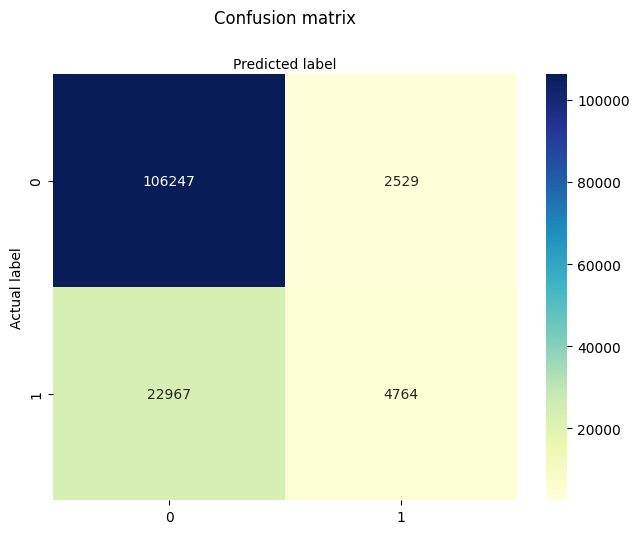

In [ ]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [154]:
target_names = ['not readmission', 'readmission']
print(classification_report(y_test, y_pred, target_names=target_names))

                 precision    recall  f1-score   support

not readmission       0.82      0.98      0.89    108776
    readmission       0.65      0.17      0.27     27731

       accuracy                           0.81    136507
      macro avg       0.74      0.57      0.58    136507
   weighted avg       0.79      0.81      0.77    136507



In [ ]:
sensitivity = metrics.recall_score(y_test, y_pred)
specificity = metrics.recall_score(np.logical_not(y_test), np.logical_not(y_pred))
print("Sensitivity =",round(sensitivity,2)) #  TP / (TP + FN) - Ideally want less FN
print("Specificity =",round(specificity,2)) # TN / (TN + FP)

Sensitivity = 0.17
Specificity = 0.98


c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


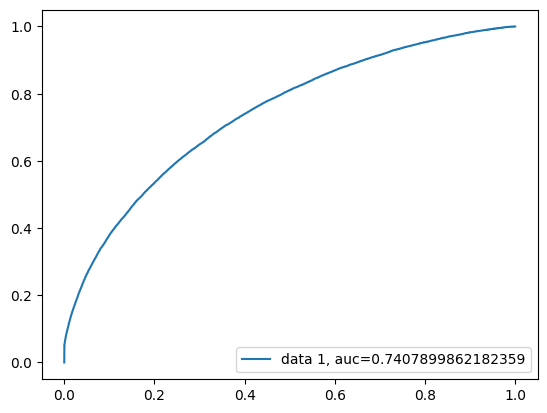

In [178]:
y_pred_proba = logreg.predict_proba(X_test)[::,1] # gets confidence level for each prediction
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [156]:
coef = logreg.coef_[0]  # For binary classification
feature_names = X_train.columns  

In [157]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef),
    'Odds Ratio': np.exp(coef),
    'Diagnosis Name': "",
    'Procedure Name': "",
    "Medication Name": ""
})

In [158]:
# Prepare lookup tables
diagnosis_lookup = df_admit_diagnosis['diagnosis_converted'].unique()
proc_lookup = df_admit_diagnosis['procedure_converted'].unique()
diagnosis_lookup = diagnosis_lookup[diagnosis_lookup != 'Other Diagnosis']
proc_lookup = proc_lookup[proc_lookup != 'Other Procedure']
medication_lookup = df_medi['medication_grouped'].unique()  

# Loop through each row
for idx, row in coef_df.iterrows():
    feature = row['Feature']

    if feature in diagnosis_lookup:
        coef_df.at[idx, 'Diagnosis Name'] = feature
    
    if feature in proc_lookup:
        coef_df.at[idx, 'Procedure Name'] = feature

    # If it's a medication, keep the name
    if feature in medication_lookup:
        coef_df.at[idx, 'Medication Name'] = feature



In [159]:
coef_df_diagnosis = coef_df[['Feature','Coefficient','Abs_Coefficient','Odds Ratio','Diagnosis Name']].sort_values(by=['Odds Ratio','Diagnosis Name'], ascending=False)
# Filter to keep only non-blank 'Diagnosis Name'
coef_df_diagnosis = coef_df_diagnosis[coef_df_diagnosis['Diagnosis Name'].notna() & (coef_df_diagnosis['Diagnosis Name'] != '')]
pd.set_option('max_colwidth', 400)
coef_df_diagnosis.head(10)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Diagnosis Name
92,antineoplastic immunotherapy,0.911484,0.911484,2.488012,antineoplastic immunotherapy
254,surgical abnormal patient later mention misadventure time,0.704707,0.704707,2.023253,surgical abnormal patient later mention misadventure time
256,surgical operations abnormal patient later mention misadventure time operation,0.601453,0.601453,1.824768,surgical operations abnormal patient later mention misadventure time operation
232,pleural effusion,0.424643,0.424643,1.529045,pleural effusion
89,alcohol abuse,0.406342,0.406342,1.501316,alcohol abuse
219,outcome delivery single liveborn,0.393163,0.393163,1.481660,outcome delivery single liveborn
104,bacteremia,0.354679,0.354679,1.425723,bacteremia
88,adverse effect antineoplastic immunosuppressive drugs,0.308336,0.308336,1.361158,adverse effect antineoplastic immunosuppressive drugs
109,bloodsampling abnormal patient later mention misadventure time,0.305361,0.305361,1.357115,bloodsampling abnormal patient later mention misadventure time
253,suicidal ideation,0.304042,0.304042,1.355326,suicidal ideation


In [160]:
coef_df_proc = coef_df[['Feature','Coefficient','Abs_Coefficient','Odds Ratio','Procedure Name']].sort_values(by=['Odds Ratio','Procedure Name'], ascending=False)
# Filter to keep only non-blank 'Procedure Name'
coef_df_proc = coef_df_proc[coef_df_proc['Procedure Name'].notna() & (coef_df_proc['Procedure Name'] != '')]
coef_df_proc.head(10)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Procedure Name
406,operations bladder,0.815659,0.815659,2.260665,operations bladder
376,laparoscopic repair hernia abdominal wall graft prosthesis,0.758095,0.758095,2.134206,laparoscopic repair hernia abdominal wall graft prosthesis
428,reconstructive refractive surgery cornea,0.753948,0.753948,2.125375,reconstructive refractive surgery cornea
375,laparoscopic incisional hernia repair graft prosthesis,0.612112,0.612112,1.844323,laparoscopic incisional hernia repair graft prosthesis
296,biopsy cornea,0.584078,0.584078,1.793337,biopsy cornea
411,osteoclasis patella,0.565362,0.565362,1.760085,osteoclasis patella
427,radical cystectomy,0.563517,0.563517,1.756840,radical cystectomy
373,keratoprosthesis,0.469942,0.469942,1.599902,keratoprosthesis
464,therapeutic leukopheresis,0.441232,0.441232,1.554622,therapeutic leukopheresis
359,incision excision congenital septum uterus,0.417599,0.417599,1.518311,incision excision congenital septum uterus


In [161]:
coef_df_medi = coef_df[['Feature','Coefficient','Abs_Coefficient','Odds Ratio','Medication Name']].sort_values(by=['Odds Ratio','Medication Name'], ascending=False)
# Filter to keep only non-blank 'Medication Name'
coef_df_medi = coef_df_medi[coef_df_medi['Medication Name'].notna() & (coef_df_medi['Medication Name'] != '')]
coef_df_medi.head(10)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Medication Name
672,vancomycin oral liquid,0.553973,0.553973,1.740153,vancomycin oral liquid
648,rifaximin,0.553345,0.553345,1.739060,rifaximin
500,atovaquone suspension,0.471003,0.471003,1.601600,atovaquone suspension
661,sulfameth/trimethoprim ss,0.387680,0.387680,1.473558,sulfameth/trimethoprim ss
481,acyclovir,0.292424,0.292424,1.339671,acyclovir
596,meropenem,0.279293,0.279293,1.322195,meropenem
551,fluconazole,0.273631,0.273631,1.314729,fluconazole
487,amiodarone,0.252755,0.252755,1.287567,amiodarone
657,sodium chloride,0.250719,0.250719,1.284949,sodium chloride
600,metoclopramide,0.249194,0.249194,1.282991,metoclopramide


In [163]:
coef_df[coef_df['Feature'].str.contains('admission_location')].sort_values(by='Odds Ratio', ascending=False)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
14,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,4.989713,4.989713,146.894217,,,
19,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,0.932577,0.932577,2.541050,,,
11,admission_location_CLINIC REFERRAL,-0.113317,0.113317,0.892868,,,
20,admission_location_WALK-IN/SELF REFERRAL,-0.198202,0.198202,0.820204,,,
16,admission_location_PHYSICIAN REFERRAL,-0.203661,0.203661,0.815739,,,
12,admission_location_EMERGENCY ROOM,-0.219906,0.219906,0.802594,,,
13,admission_location_INFORMATION NOT AVAILABLE,-0.478168,0.478168,0.619918,,,
17,admission_location_PROCEDURE SITE,-0.509547,0.509547,0.600768,,,
15,admission_location_PACU,-0.581992,0.581992,0.558784,,,
18,admission_location_TRANSFER FROM HOSPITAL,-0.778850,0.778850,0.458933,,,


In [164]:
coef_df[coef_df['Feature'].str.contains('admission_type')].sort_values(by='Odds Ratio', ascending=False)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
3,admission_type_DIRECT EMER.,0.868642,0.868642,2.383671,,,
5,admission_type_ELECTIVE,0.264970,0.264970,1.303391,,,
8,admission_type_OBSERVATION ADMIT,0.088459,0.088459,1.092489,,,
7,admission_type_EW EMER.,0.051525,0.051525,1.052875,,,
4,admission_type_DIRECT OBSERVATION,-0.048616,0.048616,0.952547,,,
10,admission_type_URGENT,-0.088805,0.088805,0.915024,,,
6,admission_type_EU OBSERVATION,-0.198693,0.198693,0.819802,,,
9,admission_type_SURGICAL SAME DAY ADMISSION,-0.675227,0.675227,0.509041,,,


In [165]:
coef_df[coef_df['Feature'].str.contains('discharge_location')].sort_values(by='Odds Ratio', ascending=False)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
23,discharge_location_CHRONIC/LONG TERM ACUTE CARE,0.665753,0.665753,1.945956,,,
24,discharge_location_DIED,0.547405,0.547405,1.728761,,,
28,discharge_location_HOSPICE,0.510705,0.510705,1.666465,,,
27,discharge_location_HOME HEALTH CARE,0.369086,0.369086,1.446412,,,
21,discharge_location_AGAINST ADVICE,0.331707,0.331707,1.393345,,,
...,...,...,...,...,...,...,...
22,discharge_location_ASSISTED LIVING,0.125597,0.125597,1.133825,,,
25,discharge_location_HEALTHCARE FACILITY,-0.022633,0.022633,0.977622,,,
29,discharge_location_OTHER FACILITY,-0.031374,0.031374,0.969114,,,
30,discharge_location_PSYCH FACILITY,-0.149980,0.149980,0.860725,,,


In [166]:
coef_df[coef_df['Feature'].str.contains('insurance')].sort_values(by='Odds Ratio', ascending=False)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
35,insurance_Other,-0.044127,0.044127,0.956832,,,
33,insurance_Medicare,-0.134141,0.134141,0.874467,,,
34,insurance_No charge,-0.139432,0.139432,0.869852,,,
36,insurance_Private,-0.266149,0.266149,0.766325,,,


In [168]:
coef_df[coef_df['Feature'].str.contains('race_')].sort_values(by='Odds Ratio', ascending=False)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
60,race_PORTUGUESE,0.047435,0.047435,1.048578,,,
61,race_SOUTH AMERICAN,0.000367,0.000367,1.000367,,,
38,race_ASIAN - ASIAN INDIAN,-0.019495,0.019495,0.980694,,,
66,race_WHITE - EASTERN EUROPEAN,-0.039188,0.039188,0.961570,,,
43,race_BLACK/AFRICAN AMERICAN,-0.062950,0.062950,0.938991,,,
...,...,...,...,...,...,...,...
53,race_HISPANIC/LATINO - MEXICAN,-0.478288,0.478288,0.619844,,,
47,race_HISPANIC/LATINO - CENTRAL AMERICAN,-0.546195,0.546195,0.579150,,,
59,race_PATIENT DECLINED TO ANSWER,-0.582570,0.582570,0.558461,,,
62,race_UNABLE TO OBTAIN,-0.965801,0.965801,0.380678,,,


In [169]:
coef_df[coef_df['Feature'].str.contains('marital_status')].sort_values(by='Odds Ratio', ascending=False)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
71,marital_status_SINGLE,0.017689,0.017689,1.017846,,,
72,marital_status_WIDOWED,0.012944,0.012944,1.013028,,,
70,marital_status_MARRIED,0.007846,0.007846,1.007877,,,


In [171]:
coef_df[coef_df['Feature'].str.contains('anchor_age')].sort_values(by='Odds Ratio', ascending=False)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
2,anchor_age,-0.004632,0.004632,0.995379,,,


In [172]:
coef_df[coef_df['Feature'].str.contains('gender')].sort_values(by='Odds Ratio', ascending=False)

,Feature,Coefficient,Abs_Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
69,gender_M,0.129846,0.129846,1.138653,,,
